# **1. Setup and Introduction**

In [ ]:
import pandas as pd
import numpy as np
import os
import dask.dataframe as dd
from IPython.display import display # Just use for display purpose
import psutil
import time
import csv
import polars as pl
import threading

# **2. Dataset Details**



*   **Source:** [UK Housing Prices Paid](https://www.kaggle.com/datasets/hm-land-registry/uk-housing-prices-paid)
*   **Size:** 2.41 GB
*   **Columns:** 11
*   **Records:** 22489348 rows
*   **Domain:** Housing



# **3. Load and Inspect Data**

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"yasminbatrisyia","key":"9d5df4331a995d19b30b7863ee2434e7"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d hm-land-registry/uk-housing-prices-paid

Dataset URL: https://www.kaggle.com/datasets/hm-land-registry/uk-housing-prices-paid
License(s): other
uk-housing-prices-paid.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip uk-housing-prices-paid.zip

Archive:  uk-housing-prices-paid.zip
replace price_paid_records.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [ ]:
df = pd.read_csv('price_paid_records.csv', low_memory=False)
display(df.head())
df.info()

,Transaction unique identifier,Price,Date of Transfer,Property Type,Old/New,Duration,Town/City,District,County,PPDCategory Type,Record Status - monthly file only
0,{81B82214-7FBC-4129-9F6B-4956B4A663AD},25000,1995-08-18 00:00,T,N,F,OLDHAM,OLDHAM,GREATER MANCHESTER,A,A
1,{8046EC72-1466-42D6-A753-4956BF7CD8A2},42500,1995-08-09 00:00,S,N,F,GRAYS,THURROCK,THURROCK,A,A
2,{278D581A-5BF3-4FCE-AF62-4956D87691E6},45000,1995-06-30 00:00,T,N,F,HIGHBRIDGE,SEDGEMOOR,SOMERSET,A,A
3,{1D861C06-A416-4865-973C-4956DB12CD12},43150,1995-11-24 00:00,T,N,F,BEDFORD,NORTH BEDFORDSHIRE,BEDFORDSHIRE,A,A
4,{DD8645FD-A815-43A6-A7BA-4956E58F1874},18899,1995-06-23 00:00,S,N,F,WAKEFIELD,LEEDS,WEST YORKSHIRE,A,A


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22489348 entries, 0 to 22489347
Data columns (total 11 columns):
 #   Column                             Dtype 
---  ------                             ----- 
 0   Transaction unique identifier      object
 1   Price                              int64 
 2   Date of Transfer                   object
 3   Property Type                      object
 4   Old/New                            object
 5   Duration                           object
 6   Town/City                          object
 7   District                           object
 8   County                             object
 9   PPDCategory Type                   object
 10  Record Status - monthly file only  object
dtypes: int64(1), object(10)
memory usage: 1.8+ GB


# **3. Apply Big Data Handling Strategies**

**Strategy 1: Load Less Data**

In [ ]:
def measure_performance(func, description="", *args, **kwargs):
    process = psutil.Process(os.getpid())
    total_ram = psutil.virtual_memory().total / 1024 / 1024  # MB

    cpu_percent = []

    def track_cpu():
        while not done[0]:
            cpu_percent.append(process.cpu_percent(interval=0.1))

    done = [False]
    cpu_thread = threading.Thread(target=track_cpu)
    cpu_thread.start()

    mem_before = process.memory_info().rss / 1024 / 1024  # MB
    start_time = time.time()

    try:
        result = func(*args, **kwargs)
        success = True
    except Exception as e:
        result = None
        success = False
        error_message = str(e)

    end_time = time.time()
    mem_after = process.memory_info().rss / 1024 / 1024  # MB

    done[0] = True
    cpu_thread.join()

    exec_time = round(end_time - start_time, 4)
    mem_diff_mb = mem_after - mem_before

    # convert dask to pandas safely
    if isinstance(result, dd.DataFrame):
      result = result.head(100000)

    if isinstance(result, (pd.DataFrame, pl.DataFrame)):
        num_records = len(result)
        throughput = round(num_records / exec_time, 2)
    else:
        throughput = None

    performance = {
        "Description": description,
        "Memory Used (MB)": round(mem_diff_mb, 2),
        "Execution Time (s)": exec_time,
        "Success": success,
        "Average CPU (%)": round(sum(cpu_percent) / len(cpu_percent), 2) if cpu_percent else 0.0,
        "Throughput (records/sec)": throughput
    }

    if not success:
        performance["Error"] = error_message

    return performance, result

In [ ]:
file_path="price_paid_records.csv"

def load_less_data_pandas(file_path):
  cols = [
      'Price', 'Date of Transfer', 'Property Type', 'Old/New', 'Duration', 'Town/City'
  ]
  return pd.read_csv(file_path, usecols=cols)


performance_less_data, df_less_data = measure_performance(
    load_less_data_pandas,
    description="Load Less Data with Pandas",
    file_path=file_path
)

display(pd.DataFrame([performance_less_data]))


,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Load Less Data with Pandas,1093.57,31.8884,True,99.12,705251.69


**Strategy 2: Chunking**

In [ ]:
def load_with_chunking(file_path):
  chunks = []
  for chunk in pd.read_csv(file_path, chunksize=10000):
    chunks.append(chunk)
  df = pd.concat(chunks, ignore_index=True)
  return df

performance_chunking, df_chunked = measure_performance(
    load_with_chunking,
    description="Chuncked Load",
    file_path="price_paid_records.csv"
)

display(pd.DataFrame([performance_chunking]))

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Chuncked Load,5722.25,61.0781,True,99.17,368206.41


**Strategy 3: Optimized Data Type**

Converted the data with specific data type.

In [ ]:
def optimized_chunked(file_path):
  cols = ['Price', 'Date of Transfer', 'Property Type', 'Old/New', 'Duration', 'Town/City']

  dtype_map = {
      'Price': 'int32',
      'Property Type':'category',
      'Old/New' : 'category',
      'Duration': 'category',
      'Town/City': 'object'
  }

  chunks = []

  for chunk in pd.read_csv(
      file_path,
      usecols=cols,
      dtype=dtype_map,
      parse_dates=['Date of Transfer'],
      chunksize=100000
  ):
        chunks.append(chunk)

  return pd.concat(chunks, ignore_index=True)

performance_opt, df_opt = measure_performance(
    optimized_chunked,
    description="Optimized Load with Dtype",
    file_path=file_path
)

display(pd.DataFrame([performance_opt]))
df_opt.info()

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Optimized Load with Dtype,21.6,116.0844,True,102.38,193732.73


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22489348 entries, 0 to 22489347
Data columns (total 6 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Price             int32         
 1   Date of Transfer  datetime64[ns]
 2   Property Type     object        
 3   Old/New           category      
 4   Duration          object        
 5   Town/City         object        
dtypes: category(1), datetime64[ns](1), int32(1), object(3)
memory usage: 793.6+ MB


**Strategy 4 : Sampling**

To reduce the processing time and RAM crashed, the dataset size has been reduced.

In [ ]:
def sampling_chunked(file_path, sample_fraction=0.1):
  cols = [
      'Price', 'Date of Transfer', 'Property Type', 'Old/New', 'Duration', 'Town/City'
  ]

  sampled_chunks = []

  for  chunk in pd.read_csv(
      file_path,
      usecols=cols,
      chunksize=10000
  ):

      sampled_chunk = chunk.sample(frac=sample_fraction, random_state=42)
      sampled_chunks.append(sampled_chunk)

  return pd.concat(sampled_chunks, ignore_index=True)


performance_sample, df_sample = measure_performance(
    sampling_chunked,
    description="Sampling",
    file_path=file_path
)

display(pd.DataFrame([performance_sample]))

print("Sample rows:", df_sample.shape[0])
df_sample.head()

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Sampling,83.34,43.7621,True,96.64,51390.02


Sample rows: 2248935


,Price,Date of Transfer,Property Type,Old/New,Duration,Town/City
0,365000,1995-11-30 00:00,T,Y,F,LONDON
1,17500,1995-05-04 00:00,T,N,F,CAMBORNE
2,37500,1995-04-28 00:00,S,N,F,BIRMINGHAM
3,69950,1995-03-03 00:00,S,N,F,FERRYHILL
4,131000,1995-05-31 00:00,D,N,F,HALESWORTH


**Strategy 5 : Parallel Processing with Dask**

Process parallel using dask

In [ ]:
def optimized_load_dask(file_path):
  cols = [
      'Price', 'Date of Transfer', 'Property Type', 'Old/New', 'Duration', 'Town/City'
  ]

  ddf = dd.read_csv(
      file_path,
      usecols=cols,
      assume_missing=True,
      on_bad_lines="skip"
  )

  ddf.columns = ddf.columns.str.strip()

  ddf['Date of Transfer'] = dd.to_datetime(
      ddf['Date of Transfer'],
      errors='coerce'
  )

  return ddf

performance_dask, df_dask = measure_performance(
    optimized_load_dask,
    description="Parallel Processing with Dask",
    file_path=file_path
)

display(pd.DataFrame([performance_dask]))

df_dask.head(10)

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Parallel Processing with Dask,9.24,0.3845,True,17.48,260078.02


,Price,Date of Transfer,Property Type,Old/New,Duration,Town/City
0,25000.0,1995-08-18,T,N,F,OLDHAM
1,42500.0,1995-08-09,S,N,F,GRAYS
2,45000.0,1995-06-30,T,N,F,HIGHBRIDGE
3,43150.0,1995-11-24,T,N,F,BEDFORD
4,18899.0,1995-06-23,S,N,F,WAKEFIELD
5,81750.0,1995-05-19,S,N,F,SALISBURY
6,56000.0,1995-03-10,S,N,F,WITNEY
7,31000.0,1995-03-02,S,N,F,ST. AUSTELL
8,82000.0,1995-06-16,S,N,F,GREENFORD
9,10000.0,1995-05-17,T,N,F,FERNDALE


**Library 1: Full Load with Pandas**

In [ ]:
def load_with_chunking():
    chunk_size = 100000
    chunks = []
    for chunk in pd.read_csv("price_paid_records.csv", chunksize=chunk_size):
        chunks.append(chunk)
    df = pd.concat(chunks, axis=0)
    return df

# creates the 'performance_chunking' dictionary AND the 'df' variable
performance_chunking, df = measure_performance(load_with_chunking, description="Load with Pandas")

# Convert the performance results to a DataFrame for that pretty GitHub-style table
performance_df = pd.DataFrame([performance_chunking])

# Display the result
display(performance_df)

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Load with Pandas,4016.83,68.0665,True,98.77,330402.59


**Library 2: Full Load with Polars**

In [ ]:
def load_with_polars(filepath):
    df = pl.read_csv(filepath)
    return df

performance_polars, df_polars = measure_performance(
    load_with_polars,
    description="Load with Polars",
    filepath="price_paid_records.csv"
)

performance_polars = pd.DataFrame([performance_polars])
display(performance_polars)

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Load with Polars,6788.11,10.123,True,167.87,2221609.01


**Library 3: Full Load with Dask**

In [ ]:
def load_full_data_dask_and_compute(file_path):
    # Dask setup (lazy)
    ddf = dd.read_csv(
        file_path,
        assume_missing=True,
        quoting=3,
        on_bad_lines='skip',
        dtype=str
    )

    # Trigger computation and return the pandas DataFrame
    # This is where the main memory usage occurs
    df = ddf.compute()
    return df

# Measure the performance of the loading and computation
performance_dask_compute, df_dask_computed = measure_performance(
    load_full_data_dask_and_compute,
    description="Load with Dask",
    file_path="price_paid_records.csv"
)

performance_df_compute = pd.DataFrame([performance_dask_compute])
display(performance_df_compute)

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Load with Dask,4637.61,84.3621,True,120.86,266581.18


## **4. Compare Performance**
Seaborn and matplotib is used to plot the diagram to compare performance between strategies based on output of part 1 and comparison between library is been run again with pandas, polars, and dask in one single code to achieve a dynamic output result and graph.

### **4.1 Compare between 5 strategies**
1. Load less data
2. Chunking
3. Optimized data types
4. Sampling
5. Parallel processing strategy with Dask

/tmp/ipykernel_2748/2847385805.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=strategies_data, x="Strategy", y="Memory Used (MB)", ax=axes[0,0], palette="viridis")
/tmp/ipykernel_2748/2847385805.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=strategies_data, x="Strategy", y="Execution Time (s)", ax=axes[0,1], palette="magma")
/tmp/ipykernel_2748/2847385805.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=strategies_data, x="Strategy", y="Average CPU (%)", ax=axes[1,0], palette="rocket")
/tmp/ipykernel_2748/2847

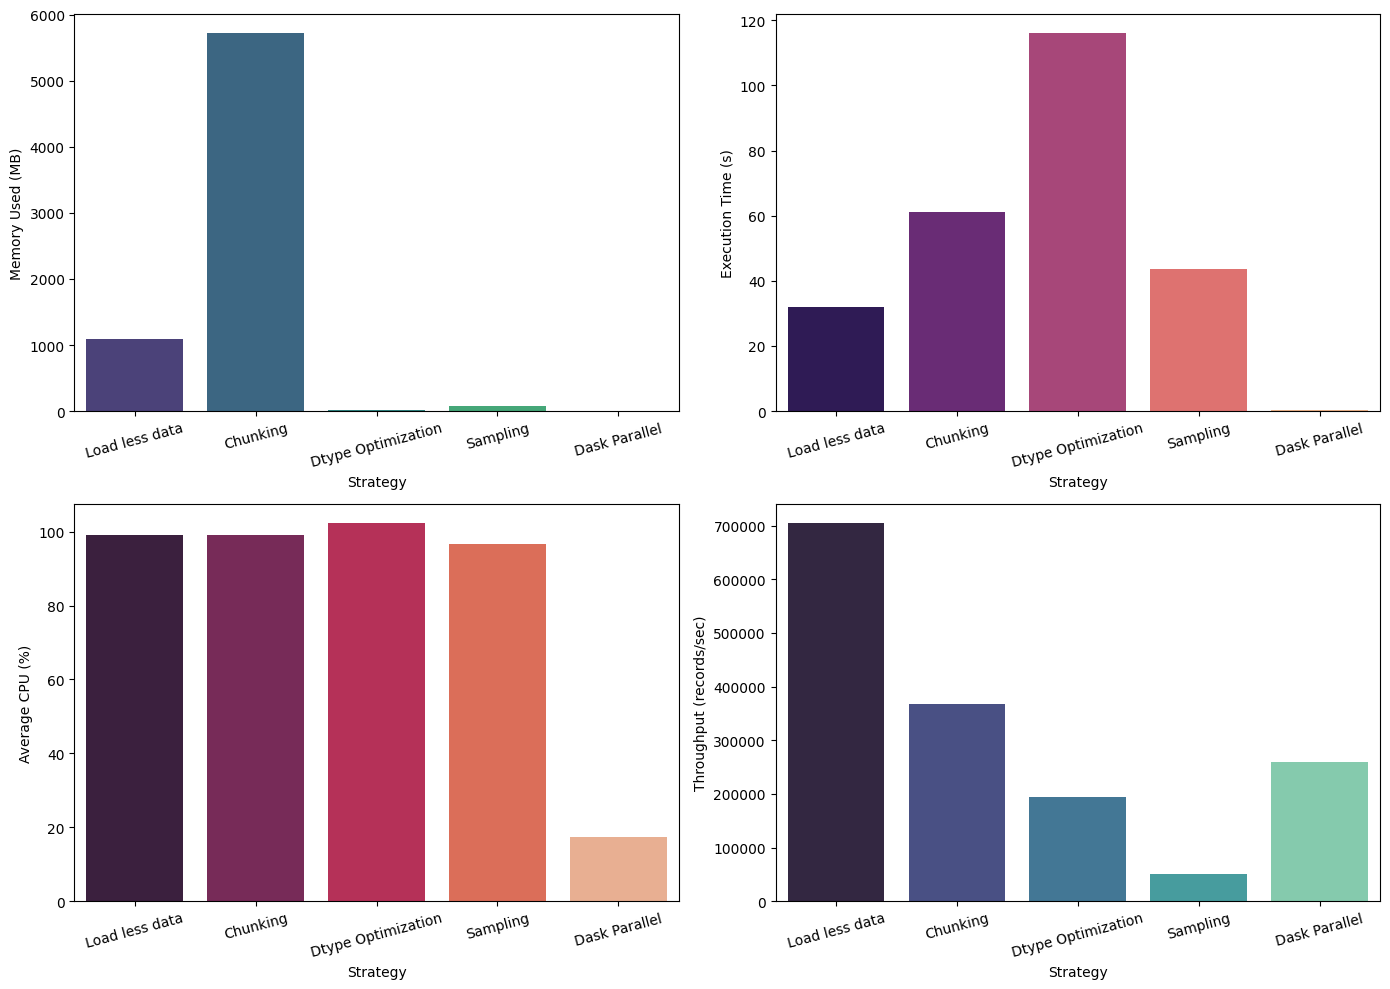

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

strategies_data = pd.DataFrame([
    performance_less_data,
    performance_chunking,
    performance_opt,
    performance_sample,
    performance_dask
])

strategies_data["Strategy"] = [
    "Load less data",
    "Chunking",
    "Dtype Optimization",
    "Sampling",
    "Dask Parallel"
]

fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.barplot(data=strategies_data, x="Strategy", y="Memory Used (MB)", ax=axes[0,0], palette="viridis")
sns.barplot(data=strategies_data, x="Strategy", y="Execution Time (s)", ax=axes[0,1], palette="magma")
sns.barplot(data=strategies_data, x="Strategy", y="Average CPU (%)", ax=axes[1,0], palette="rocket")
sns.barplot(data=strategies_data, x="Strategy", y="Throughput (records/sec)", ax=axes[1,1], palette="mako")

for ax in axes.flat:
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()

**Compare between 3 library**
1. Load with pandas
2. Load with polars
3. Load with dask

Running Pandas...
Pandas finished. Memory cleared.
Running Polars...
Polars finished. Memory cleared.
Running Dask...
Dask finished. Memory cleared.


/tmp/ipykernel_13929/2355111922.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Description", y="Memory Used (MB)", data=library_data, ax=axes[0, 0], palette="viridis")
/tmp/ipykernel_13929/2355111922.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Description", y="Execution Time (s)", data=library_data, ax=axes[0, 1], palette="magma")
/tmp/ipykernel_13929/2355111922.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Description", y="Average CPU (%)", data=library_data, ax=axes[1, 0], palette="rocket")
/tmp/ipykernel_139

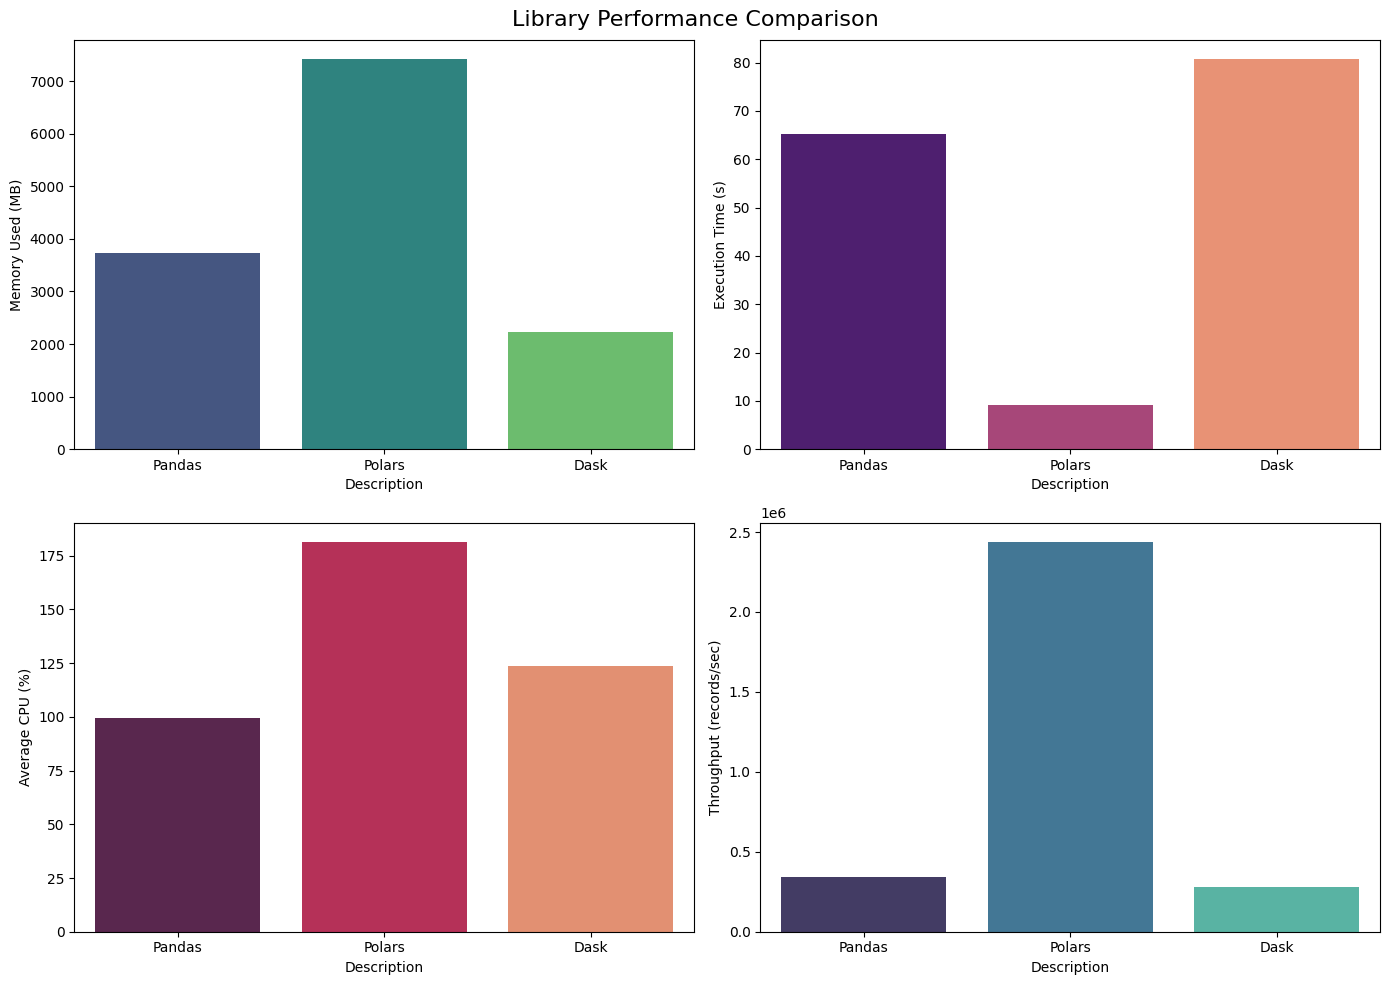

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Pandas,3727.15,65.2052,True,99.27,344901.14
1,Polars,7412.44,9.2270,True,181.34,2437341.28
2,Dask,2220.73,80.6522,True,123.53,278843.58


In [ ]:
import gc
import os
import psutil
import pandas as pd
import polars as pl
import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns

# Define Library-Specific Functions

def load_with_pandas(filepath):
    chunk_size = 100000
    chunks = [chunk for chunk in pd.read_csv(filepath, chunksize=chunk_size)]
    return pd.concat(chunks, axis=0)

def load_with_polars(filepath):
    return pl.read_csv(filepath)

def load_with_dask(filepath):
    # Dask read + compute to bring it into memory for a fair comparison
    ddf = dd.read_csv(filepath, assume_missing=True, quoting=3, on_bad_lines='skip', dtype=str)
    return ddf.compute()

# The Execution Loop

file_path = "price_paid_records.csv"
tasks = [
    ("Pandas", load_with_pandas),
    ("Polars", load_with_polars),
    ("Dask", load_with_dask)
]

all_metrics = []

for name, func in tasks:
    print(f"Running {name}...")

    # Run the measurement
    perf, result = measure_performance(func, description=name, filepath=file_path)
    all_metrics.append(perf)

    #Clean up memory immediately
    del result
    gc.collect()
    print(f"{name} finished. Memory cleared.")

# Visualization
# Convert list of dicts to a single DataFrame
library_data = pd.DataFrame(all_metrics)

# Standardize column names for plotting if they differ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(x="Description", y="Memory Used (MB)", data=library_data, ax=axes[0, 0], palette="viridis")
sns.barplot(x="Description", y="Execution Time (s)", data=library_data, ax=axes[0, 1], palette="magma")
sns.barplot(x="Description", y="Average CPU (%)", data=library_data, ax=axes[1, 0], palette="rocket")
sns.barplot(x="Description", y="Throughput (records/sec)", data=library_data, ax=axes[1, 1], palette="mako")

plt.suptitle("Library Performance Comparison", fontsize=16)
plt.tight_layout()
plt.show()

# Display the final table
display(library_data)